## Predizioni statistiche sull'incasso dei film - modello di Regressione Logistica


Importazione delle librerie necessarie:

In [46]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

import requests

from bs4 import BeautifulSoup



Recupero del dataframe pulito da una cartella locale:

In [47]:
df_movies_clean = pd.read_csv("C:/Users/nicol/Downloads/df_imdb_movies_clean.csv")
df_movies_clean.head()

,movie_title,release_date,imdb_score,genre,overview,orig_title,orig_lang,budget,revenue,country,release_year,duration[min],color,director_name,review_num,movie_facebook_likes,director_facebook_likes,cast_total_facebook_likes,cast
0,the passion of the christ,02/25/2004,74.0,Drama,A graphic portrayal of the last twelve hours o...,The Passion of the Christ,English,25000000.0,6.223136e+08,AU,2004,120.0,Color,Mel Gibson,406.0,13000,0.0,705,"Christo Jivkov, Maia Morgenstern, Hristo Shopov"
1,avatar,12/17/2009,76.0,"Action, Adventure, Fantasy, Science Fiction","In the 22nd century, a paraplegic Marine is di...",Avatar,English,237000000.0,2.923706e+09,AU,2009,178.0,Color,James Cameron,723.0,33000,0.0,4834,"CCH Pounder, Joel David Moore, Wes Studi"
2,super mario bros.,06/10/1993,43.0,"Action, Adventure, Comedy, Family, Science Fic...","Mario and Luigi, plumbers from Brooklyn, find ...",Super Mario Bros.,English,42000000.0,2.084491e+07,AU,1993,104.0,Color,Annabel Jankel,36.0,0,5.0,7723,"Bob Hoskins, Fisher Stevens, Fiona Shaw"
3,creed,11/26/2015,74.0,Drama,The former World Heavyweight Champion Rocky Ba...,Creed,English,37000000.0,1.735676e+08,AU,2015,133.0,Color,Ryan Coogler,437.0,70000,0.0,15106,"Sylvester Stallone, Phylicia Rashad, Graham Mc..."
4,"the chronicles of narnia: the lion, the witch ...",12/26/2005,71.0,"Adventure, Family, Fantasy","Siblings Lucy, Edmund, Susan and Peter step th...","The Chronicles of Narnia: The Lion, the Witch ...",English,180000000.0,7.450131e+08,AU,2005,150.0,Color,Andrew Adamson,284.0,0,80.0,1317,"Jim Broadbent, Kiran Shah, Shane Rangi"


Controllo del datatype delle varie colonne:

In [48]:
df_movies_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1975 entries, 0 to 1974
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   movie_title                1975 non-null   str    
 1   release_date               1975 non-null   str    
 2   imdb_score                 1975 non-null   float64
 3   genre                      1975 non-null   str    
 4   overview                   1975 non-null   str    
 5   orig_title                 1975 non-null   str    
 6   orig_lang                  1975 non-null   str    
 7   budget                     1975 non-null   float64
 8   revenue                    1975 non-null   float64
 9   country                    1975 non-null   str    
 10  release_year               1975 non-null   int64  
 11  duration[min]              1975 non-null   float64
 12  color                      1972 non-null   str    
 13  director_name              1975 non-null   str    
 14  rev

Conversione della colonna 'release_date' in formato datetime:

In [49]:
df_movies_clean['release_date'] = df_movies_clean['release_date'].str.strip()
df_movies_clean['release_date'] = pd.to_datetime(df_movies_clean['release_date'], format='%m/%d/%Y')

In [52]:
df_movies_clean.rename(columns = {'budget': 'budget($)', 'revenue':'revenue($)'}, inplace = True)

___

### Definizione delle "features" utili a fare previsioni sugli incassi.

Lista di tutti i diversi generi presenti nel dataset:

In [54]:
unique_genres = df_movies_clean['genre'].str.split(',').explode().str.strip().unique()
unique_genres

<ArrowStringArray>
[          'Drama',          'Action',       'Adventure',         'Fantasy',
 'Science Fiction',          'Comedy',          'Family',       'Animation',
         'Mystery',         'Romance',        'Thriller',          'Horror',
           'Crime',             'War',        'TV Movie',         'History',
         'Western',           'Music',     'Documentary']
Length: 19, dtype: str

Ordinemanto dei generi in base all'incasso medio:

In [55]:
def avg_revenue_by_genre(genre):
    
    return df_movies_clean[df_movies_clean['genre'].str.contains(genre)]['revenue($)'].mean()
 
genre_revenue = []
 
for el in unique_genres:
    genre_revenue.append([el, avg_revenue_by_genre(el)])
 
df_genre_revenue = pd.DataFrame(genre_revenue, columns=['genre', 'average_revenue($)'])
df_genre_revenue.reset_index(drop=True, inplace=True)
df_genre_revenue.sort_values('average_revenue($)', ascending=False, inplace=True)
df_genre_revenue['average_revenue($)'] = df_genre_revenue['average_revenue($)'].round(0).astype(int)
 
df_genre_revenue

,genre,average_revenue($)
7,Animation,319638087
2,Adventure,283527045
3,Fantasy,266041595
6,Family,240377154
4,Science Fiction,225051054
1,Action,213057217
5,Comedy,150065005
10,Thriller,136604280
9,Romance,133297683
13,War,132633682


Generi più redditizi:

In [56]:
highest_paying_genres_list = df_genre_revenue['genre'].head(7)

df_movies_clean['highest_paying_genre'] = [any(g in genre for g in highest_paying_genres_list) if isinstance(genre, str) else False for genre in df_movies_clean['genre']]

df_movies_clean['highest_paying_genre'].value_counts()

highest_paying_genre
True     1486
False     489
Name: count, dtype: int64

Generi meno redditizi:

In [57]:
lowest_paying_genres_list = df_genre_revenue['genre'].tail(3)

df_movies_clean['lowest_paying_genre'] = [any(g in genre for g in lowest_paying_genres_list) if isinstance(genre, str) else False for genre in df_movies_clean['genre']]

df_movies_clean['lowest_paying_genre'].value_counts()

lowest_paying_genre
False    1641
True      334
Name: count, dtype: int64

Attori più influenti - Web scraping:

In [58]:
url = "https://www.watchmojo.com/articles/top-50-defining-actors-of-the-last-50-years"
page = requests.get(url)
soup = BeautifulSoup(page.content, "html.parser")
actor_links = soup.find_all("a", class_="item-title")

most_defining_actors = []

for actor in actor_links:
    actor_name = actor.get_text(strip=True)
    if actor_name:
        most_defining_actors.append(actor_name)

most_defining_actors


['Halle Berry',
 'Charlize Theron',
 'Dustin Hoffman',
 'Michelle Yeoh',
 'Margot Robbie',
 'Morgan Freeman',
 'Gary Oldman',
 'Amy Adams',
 'Jennifer Lawrence',
 'Matthew McConaughey',
 'Robert Downey Jr.',
 'Julianne Moore',
 'Paul Newman',
 "Lupita Nyong'o",
 'Helen Mirren',
 'Hugh Jackman',
 'Nicole Kidman',
 'Philip Seymour Hoffman',
 'Jodie Foster',
 'Ralph Fiennes',
 'Johnny Depp',
 'Angela Bassett',
 'Willem Dafoe',
 'Brad Pitt',
 'Sylvester Stallone',
 'Viola Davis',
 'Sigourney Weaver',
 'Keanu Reeves',
 'Glenn Close',
 'Christian Bale',
 'Arnold Schwarzenegger',
 'Frances McDormand',
 'Samuel L. Jackson',
 'Harrison Ford',
 'Anthony Hopkins',
 'Emma Stone',
 'Heath Ledger',
 'Joaquin Phoenix',
 'Julia Roberts',
 'Jack Nicholson',
 'Leonardo DiCaprio',
 'Robin Williams',
 'Robert De Niro',
 'Tom Cruise',
 'Cate Blanchett',
 'Daniel Day-Lewis',
 'Denzel Washington',
 'Al Pacino',
 'Tom Hanks',
 'Meryl Streep']

In [59]:
df_movies_clean['star_in_cast'] = [any(star in cast for star in most_defining_actors) if isinstance(cast, str) else False for cast in df_movies_clean['cast']]

df_movies_clean['star_in_cast'].value_counts()

star_in_cast
False    1632
True      343
Name: count, dtype: int64

Registi preferiti dal pubblico - Web scraping:

In [60]:
url_I = "https://nofilmschool.com/best-directors-of-all-time"
page = requests.get(url_I)
soup = BeautifulSoup(page.content, "html.parser")
director_links = soup.find_all("h3")

favourite_directors = []

for director in director_links:
    director_name = director.get_text(strip=True).split('. ', 1)[-1]
    if director_name:
        favourite_directors.append(director_name)

favourite_directors_top50 = favourite_directors[:49]
favourite_directors_top50

['Martin Scorsese',
 'Steven Spielberg',
 'Alfred Hitchcock',
 'Stanley Kubrick',
 'Quentin Tarantino',
 'Akira Kurosawa',
 'Christopher Nolan',
 'Francis Ford Coppola',
 'Spike Lee',
 'David Fincher',
 'Orson Welles',
 'Billy Wilder',
 'Ridley Scott',
 'Jane Campion',
 'John Ford',
 'James Cameron',
 'Ingmar Bergman',
 'Tim Burton',
 'Charlie Chaplin',
 'Federico Fellini',
 'David Lynch',
 'Peter Jackson',
 'Oscar Micheaux',
 'Roman Polanski',
 'Ang Lee',
 'John Singleton',
 'Agnes Varda',
 'Sergio Leone',
 'Jean-Luc Godard',
 'Alfonso Cuaron',
 'Sidney Lumet',
 'Clint Eastwood',
 'Jordan Peele',
 'Chantal Akerman',
 'Paul Thomas Anderson',
 'Andrei Tarkovsky',
 'John Huston',
 'David Lean',
 'Werner Herzog',
 'Nora Ephron',
 'Brian De Palma',
 'Frank Capra',
 'William Wyler',
 'Penny Marshall',
 'Joel Coen',
 'Alejandro González Iñárritu',
 'Miloš Forman',
 'Chloé Zhao',
 'Robert Altman']

In [61]:
df_movies_clean['star_director'] = [1 if director in favourite_directors_top50 else 0 for director in df_movies_clean['director_name']]

df_movies_clean['star_director'].value_counts()

star_director
0    1844
1     131
Name: count, dtype: int64

Periodo di uscita di un film:

In [62]:
def christmas_period(date):

    if (date.month == 12 and date.day >= 20) or (date.month == 1 and date.day <= 6):
        
        return 1
    
    else:
         
        return 0


df_movies_clean['christmas_period'] = df_movies_clean['release_date'].apply(christmas_period)
df_movies_clean['christmas_period'].value_counts()

christmas_period
0    1873
1     102
Name: count, dtype: int64

In [63]:
def summer_period(date):

        if (date.month in {6, 7, 8}):

            return 1

        else:

            return 0


df_movies_clean['summer_period'] = df_movies_clean['release_date'].apply(summer_period)
df_movies_clean['summer_period'].value_counts()

summer_period
0    1435
1     540
Name: count, dtype: int64

Film a colori o in bianco e nero:

In [64]:
df_movies_clean['is_color'] = [1 if el == 'Color' else 0 for el in df_movies_clean['color']]
df_movies_clean['is_color'].value_counts()

is_color
1    1918
0      57
Name: count, dtype: int64

Abbiamo poi incluso fra i vari predittori, oltre al budget e a quelli appena visti, anche l'anno di realizzazione, legato al prezzo medio dei biglietti, e la durata del film.

### Definizione della variabile "target":

In [65]:
df_movies_clean['significant_revenue'] = [1 if el >= 100000000 else 0 for el in df_movies_clean['revenue($)']] #soglia: 100 milioni di $
df_movies_clean['significant_revenue'].value_counts()

significant_revenue
0    1079
1     896
Name: count, dtype: int64

In [66]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

columns_to_normalize = df_movies_clean[['budget($)', 'release_year', 'duration[min]']]

scaler = MinMaxScaler()

df_movies_clean[['budget($)', 'release_year', 'duration[min]']] = scaler.fit_transform(df_movies_clean[['budget($)', 'release_year', 'duration[min]']])

df_movies_clean_normalized = df_movies_clean[['significant_revenue', 'budget($)', 'release_year', 'duration[min]', 'highest_paying_genre', 'lowest_paying_genre', 'star_director', 'star_in_cast', 'christmas_period', 'summer_period', 'is_color']]


Matrice di correlazione fra i vari predittori ed il "target":

In [67]:
df_movies_clean_normalized[['significant_revenue','budget($)', 'duration[min]','release_year','christmas_period','summer_period','star_director','star_in_cast','highest_paying_genre','lowest_paying_genre','is_color']].corr()

,significant_revenue,budget($),duration[min],release_year,christmas_period,summer_period,star_director,star_in_cast,highest_paying_genre,lowest_paying_genre,is_color
significant_revenue,1.000000,0.521180,0.176452,0.142564,0.081458,0.057086,0.063628,0.205086,0.195211,-0.161504,0.023445
budget($),0.521180,1.000000,0.301836,0.255593,0.065508,0.080087,0.060996,0.214412,0.278099,-0.232132,0.062081
duration[min],0.176452,0.301836,1.000000,-0.155349,0.055642,-0.005446,0.300392,0.209213,-0.143078,-0.130160,-0.056786
release_year,0.142564,0.255593,-0.155349,1.000000,-0.019605,-0.020643,-0.224228,0.012585,0.071634,-0.055072,0.172706
christmas_period,0.081458,0.065508,0.055642,-0.019605,1.000000,-0.143154,0.048123,0.056079,0.038455,-0.044247,-0.014434
summer_period,0.057086,0.080087,-0.005446,-0.020643,-0.143154,1.000000,-0.035687,0.000653,0.099228,-0.016127,0.010754
star_director,0.063628,0.060996,0.300392,-0.224228,0.048123,-0.035687,1.000000,0.135609,-0.115799,-0.065969,-0.160656
star_in_cast,0.205086,0.214412,0.209213,0.012585,0.056079,0.000653,0.135609,1.000000,-0.015715,-0.128383,0.039114
highest_paying_genre,0.195211,0.278099,-0.143078,0.071634,0.038455,0.099228,-0.115799,-0.015715,1.000000,-0.276346,0.062273
lowest_paying_genre,-0.161504,-0.232132,-0.130160,-0.055072,-0.044247,-0.016127,-0.065969,-0.128383,-0.276346,1.000000,-0.027113


Non si osservano correlazioni particolarmente significative fra i vari predittori, tuttavia si riscontrano correlazioni piuttosto deboli, ad eccezione di quella fra il budget ed il target, anche fra i vari predittori ed il target. Si decide quindi di escludere dai predittori la variabile 'is_color', che mostra una correlazione con il target quasi nulla.

### Assegnazione della variabile target e delle variabili predittrici e divisione del dataset in TRAINING set e TEST set.

In [68]:
y = df_movies_clean_normalized['significant_revenue']
X = df_movies_clean_normalized[['budget($)','duration[min]','release_year', 'star_director', 'star_in_cast', 'highest_paying_genre', 'lowest_paying_genre', 'christmas_period', 'summer_period']] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Allenamento del modello sul TRANING set:

In [69]:
log_reg = LogisticRegression(max_iter=1000, class_weight = 'balanced')
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Calcolo dell'intercetta e dei coefficienti della regressione logistica:

In [70]:
print('Intercept:', log_reg.intercept_)
print('Coefficients:', log_reg.coef_[0])

Intercept: [-2.83562764]
Coefficients: [ 8.08249998  1.21703744  1.01627766  0.11106523  0.80408104  0.58116925
 -0.02789548  0.47722045  0.25777141]


Definizione delle predizioni sulla base del TEST set:

In [71]:
y_pred = log_reg.predict(X_test)

Matrice di confusione:

In [72]:
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
confusion_matrix

array([[269,  57],
       [ 92, 175]])

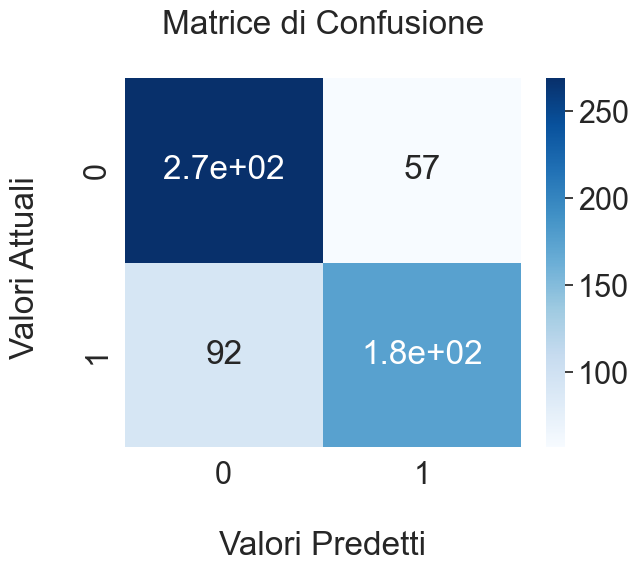

In [73]:
sns.set(font_scale=2)

ax = sns.heatmap(confusion_matrix, annot=True, cmap='Blues')

ax.set_title('Matrice di Confusione\n');
ax.set_xlabel('\nValori Predetti')
ax.set_ylabel('Valori Attuali \n');

ax.yaxis.set_ticklabels(['0','1'])
ax.xaxis.set_ticklabels(['0','1'])

plt.show()

Parametri indicativi della bontà del modello:

In [74]:
print('Accuratezza:' , (round(metrics.accuracy_score(y_test, y_pred), 3))*100,'%')

Accuratezza: 74.9 %


In [75]:
print ('Precisione:' , (round(metrics.precision_score(y_test, y_pred), 3))*100,'%')

Precisione: 75.4 %


In [76]:
print ('Richiamo:' , (round(metrics.recall_score(y_test, y_pred), 3))*100,'%')

Richiamo: 65.5 %


In [77]:
from sklearn.metrics import f1_score

score = f1_score(y_test, y_pred, average = 'binary')

print (f"F1 Score: {round(score, 3)*100} %")

F1 Score: 70.1 %


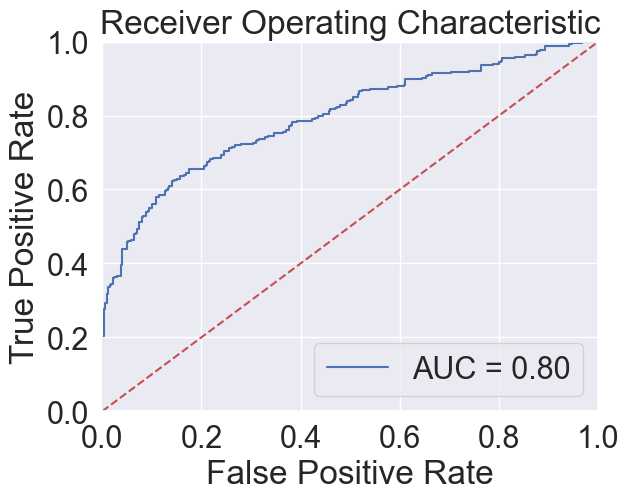

In [78]:

probs = log_reg.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

## Conclusioni:

I risultati relativi ai parametri di accuratezza, precisione, richiamo e ROC-AUC mostrano come il modello riesca solo parzialmente a produrre predizioni corrette sull'incasso di un film. Va considerato infatti che a incidere sull'incasso finale di un film esistono anche fattori esterni al modello, come l'efficacia della promozione di un film, la competizione con altri film usciti nello stesso periodo, l'originalità della trama ed, in generale, i temi trattati dal film stesso ed il passa-parola fra le persone durante i mesi di uscita del film.